# Heart Disease - Exploratory Data Analysis

Dataset: UCI Heart Disease (multi-source: Cleveland, Hungarian, etc.)

Note: this version stores categorical features as text (e.g. 'typical angina' instead of 0/1/2/3), has an `id` and `dataset` (source hospital) column we don't need for prediction, and the target `num` is a 0-4 severity scale rather than plain 0/1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.info()

Shape: (920, 16)

Column names: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64

In [4]:
# Drop columns not useful for prediction
df = df.drop(columns=['id', 'dataset'])

# Missing values - this multi-source dataset commonly has real gaps,
# especially in ca, thal, slope for non-Cleveland sources
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


In [5]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Target Variable: `num`

Originally 0-4 (severity of heart disease). For a binary risk classifier, we convert this to 0 (no disease) vs 1 (any disease present).

Original num distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


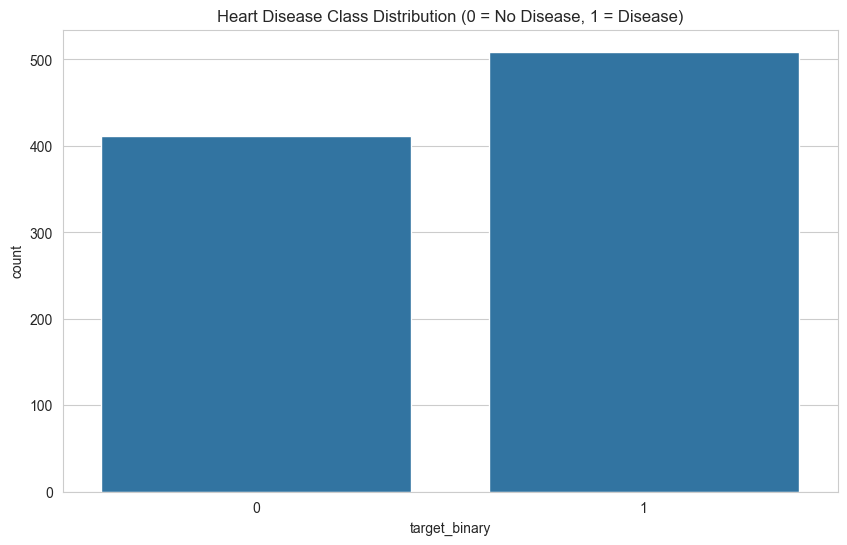

target_binary
1    0.553261
0    0.446739
Name: proportion, dtype: float64


In [6]:
print('Original num distribution:')
print(df['num'].value_counts().sort_index())

df['target_binary'] = (df['num'] > 0).astype(int)

sns.countplot(x='target_binary', data=df)
plt.title('Heart Disease Class Distribution (0 = No Disease, 1 = Disease)')
plt.show()

print(df['target_binary'].value_counts(normalize=True))

## Categorical Feature Value Counts

These are stored as text and will need to be one-hot encoded before modeling (done in `04_heart_models.ipynb`).

In [7]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- sex ---
sex
Male      726
Female    194
Name: count, dtype: int64

--- cp ---
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

--- fbs ---
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

--- restecg ---
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

--- exang ---
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

--- slope ---
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

--- thal ---
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64



## Numerical Feature Distributions

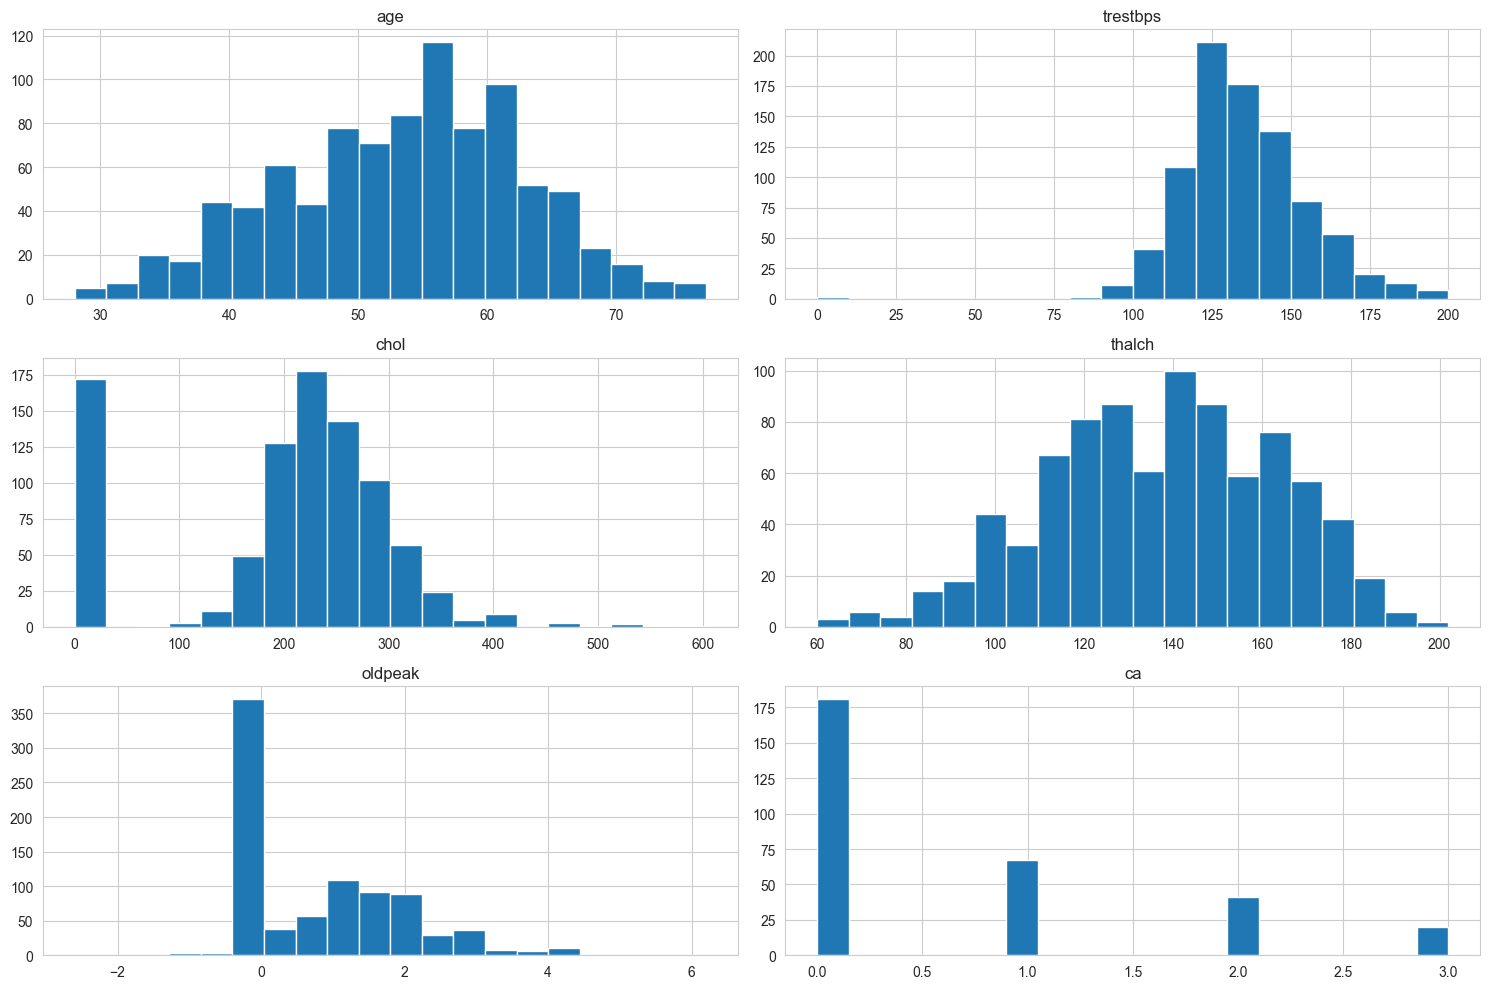

In [8]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

## Correlation Heatmap (numeric features only)

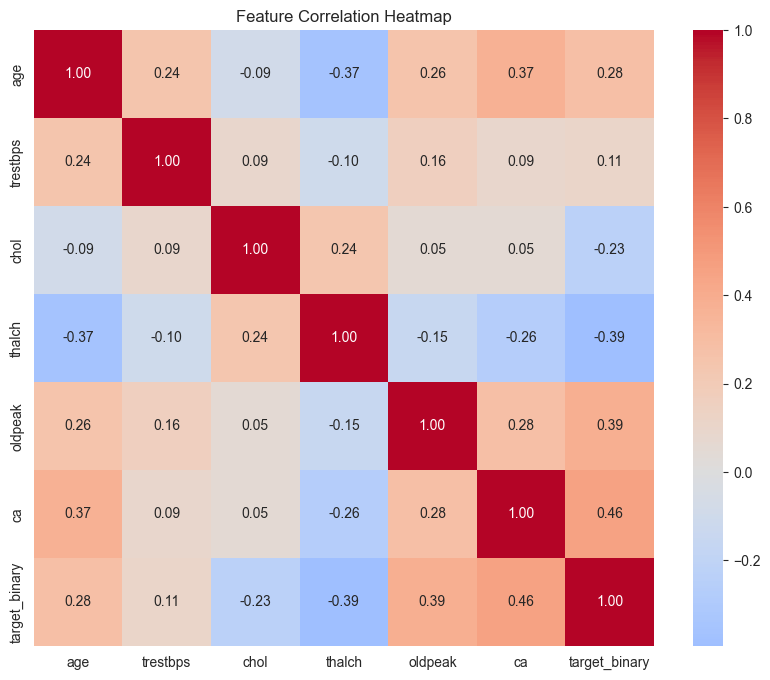

In [9]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['target_binary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

## Outlier Check

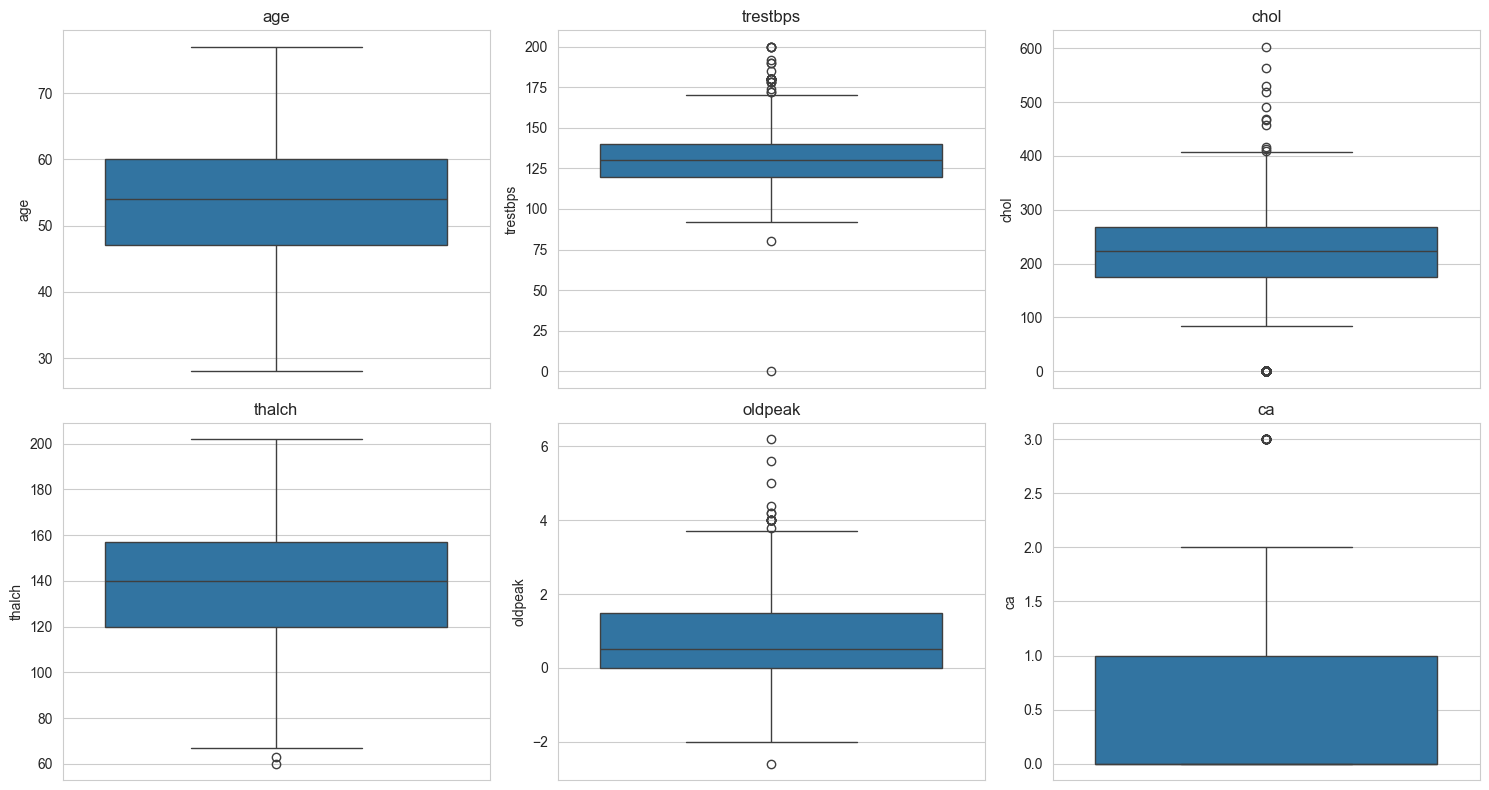

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Key Takeaways (fill in after running)

- Missing values found in: ...
- Class balance (target_binary): ...
- Numeric features most correlated with disease: ...
- Categorical features that look most informative (e.g. cp, thal): ...
- Cleaning plan for modeling notebook: drop id/dataset, impute missing values, one-hot encode text categoricals, binarize target